In [1]:
# =========================================================
# CELL 1: Imports & Global Configuration
# =========================================================

import os
import warnings
import joblib
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Scikit-Learn
# ---------------------------------------------------------

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.neighbors import (
    KNeighborsRegressor
)

# ---------------------------------------------------------
# Boosting Models
# ---------------------------------------------------------

import xgboost as xgb
import lightgbm as lgb

# ---------------------------------------------------------
# Global Settings
# ---------------------------------------------------------

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    150
)

pd.set_option(
    "display.max_colwidth",
    None
)

plt.rcParams["figure.figsize"] = (
    10,
    6
)

print("=" * 70)
print("🚀 Car Price Prediction Project Initialized")
print("=" * 70)

print(f"\nRandom State : {RANDOM_STATE}")

print(
    f"NumPy Version : "
    f"{np.__version__}"
)

print(
    f"Pandas Version : "
    f"{pd.__version__}"
)

print("\n✅ CELL 1 Completed Successfully")

🚀 Car Price Prediction Project Initialized

Random State : 42
NumPy Version : 2.4.0
Pandas Version : 3.0.2

✅ CELL 1 Completed Successfully


In [2]:
# =========================================================
# CELL 2: Dataset Loading
# =========================================================

print("🚀 Loading datasets...\n")

# ---------------------------------------------------------
# Dataset Files
# ---------------------------------------------------------

file_brand_mapping = {
    "audi.csv": "Audi",
    "bmw.csv": "BMW",
    "ford.csv": "Ford",
    "toyota.csv": "Toyota",
    "vw.csv": "Volkswagen",
    "vauxhall.csv": "Vauxhall",
    "hyundi.csv": "Hyundai",
    "merc.csv": "Mercedes-Benz",
    "cclass.csv": "Mercedes-Benz",
    "focus.csv": "Ford"
}

# ---------------------------------------------------------
# Required Columns
# ---------------------------------------------------------

required_columns = [
    "model",
    "year",
    "price",
    "transmission",
    "mileage",
    "fuelType",
    "tax",
    "mpg",
    "engineSize"
]

# ---------------------------------------------------------
# Load Files
# ---------------------------------------------------------

all_dataframes = []

for file_name, brand_name in file_brand_mapping.items():

    if not os.path.exists(file_name):

        print(f"❌ File not found: {file_name}")
        continue

    temp_df = pd.read_csv(file_name)

    if "tax(£)" in temp_df.columns:

        temp_df.rename(
            columns={
                "tax(£)": "tax"
            },
            inplace=True
        )

    temp_df["brand"] = brand_name

    missing_cols = [

        col

        for col in required_columns

        if col not in temp_df.columns

    ]

    if len(missing_cols) > 0:

        print(
            f"⚠️ Missing columns in {file_name}: "
            f"{missing_cols}"
        )

        continue

    all_dataframes.append(
        temp_df
    )

    print(
        f"✅ Loaded: {file_name}"
    )

# ---------------------------------------------------------
# Merge Datasets
# ---------------------------------------------------------

df = pd.concat(

    all_dataframes,

    ignore_index=True

)

# ---------------------------------------------------------
# Remove Duplicates
# ---------------------------------------------------------

before_rows = len(df)

df.drop_duplicates(
    inplace=True
)

after_rows = len(df)

# ---------------------------------------------------------
# Reset Index
# ---------------------------------------------------------

df.reset_index(
    drop=True,
    inplace=True
)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)

print("📊 DATASET SUMMARY")

print("=" * 60)

print(
    f"\nRows: {len(df):,}"
)

print(
    f"Columns: {df.shape[1]}"
)

print(
    f"Duplicates Removed: "
    f"{before_rows - after_rows:,}"
)

print("\nDataset Shape:")

print(df.shape)

display(
    df.head()
)

print(
    "\n✅ CELL 2 Completed Successfully"
)

🚀 Loading datasets...

✅ Loaded: audi.csv
✅ Loaded: bmw.csv
✅ Loaded: ford.csv
✅ Loaded: toyota.csv
✅ Loaded: vw.csv
✅ Loaded: vauxhall.csv
✅ Loaded: hyundi.csv
✅ Loaded: merc.csv
⚠️ Missing columns in cclass.csv: ['tax', 'mpg']
⚠️ Missing columns in focus.csv: ['tax', 'mpg']

📊 DATASET SUMMARY

Rows: 91,524
Columns: 10
Duplicates Removed: 1,396

Dataset Shape:
(91524, 10)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,Audi



✅ CELL 2 Completed Successfully


In [3]:
# =========================================================
# CELL 3: Data Cleaning
# =========================================================

print("🚀 Starting Data Cleaning...\n")

df_model = df.copy()

# ---------------------------------------------------------
# Missing Values
# ---------------------------------------------------------

print("📋 Missing Values Before Cleaning:\n")

display(
    df_model.isnull().sum()
)

df_model.dropna(
    inplace=True
)

# ---------------------------------------------------------
# Remove Invalid Values
# ---------------------------------------------------------

df_model = df_model[

    (df_model["price"] > 0)

    &

    (df_model["year"] >= 1990)

    &

    (df_model["mileage"] >= 0)

    &

    (df_model["engineSize"] > 0)

    &

    (df_model["mpg"] > 0)

]

# ---------------------------------------------------------
# Remove Extreme Price Outliers
# ---------------------------------------------------------

q1 = df_model["price"].quantile(0.01)

q99 = df_model["price"].quantile(0.99)

df_model = df_model[

    (df_model["price"] >= q1)

    &

    (df_model["price"] <= q99)

]

# ---------------------------------------------------------
# Remove Extreme Mileage Outliers
# ---------------------------------------------------------

mileage_q99 = (
    df_model["mileage"]
    .quantile(0.995)
)

df_model = df_model[

    df_model["mileage"]
    <= mileage_q99

]

# ---------------------------------------------------------
# Reset Index
# ---------------------------------------------------------

df_model.reset_index(

    drop=True,

    inplace=True

)

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print("\n" + "=" * 60)

print("📊 CLEANING SUMMARY")

print("=" * 60)

print(
    f"\nFinal Shape: "
    f"{df_model.shape}"
)

print(
    f"\nRemaining Missing Values: "
    f"{df_model.isnull().sum().sum()}"
)

print("\nData Types:\n")

display(
    df_model.dtypes
)

print(
    "\n✅ CELL 3 Completed Successfully"
)

🚀 Starting Data Cleaning...

📋 Missing Values Before Cleaning:



model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64


📊 CLEANING SUMMARY

Final Shape: (89014, 10)

Remaining Missing Values: 0

Data Types:



model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
tax               int64
mpg             float64
engineSize      float64
brand               str
dtype: object


✅ CELL 3 Completed Successfully


🚀 Starting Exploratory Data Analysis...

📊 DATASET OVERVIEW

Shape: (89014, 10)

Data Types:



model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
tax               int64
mpg             float64
engineSize      float64
brand               str
dtype: object


Missing Values:



model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64


📈 Numerical Statistics:



,count,mean,std,min,25%,50%,75%,max
year,89014.0,2017.128542,1.892328,1996.0,2016.00,2017.0,2019.0,2060.0
price,89014.0,16635.108331,8587.667806,3990.0,10220.25,14500.0,20899.0,52995.0
mileage,89014.0,22505.941953,18877.057923,1.0,7894.00,17793.5,32165.5,101040.0
tax,89014.0,119.607253,62.950681,0.0,125.00,145.0,145.0,580.0
mpg,89014.0,55.212602,14.040865,0.3,47.10,54.3,62.8,470.8
engineSize,89014.0,1.667533,0.530122,0.6,1.30,1.6,2.0,6.6


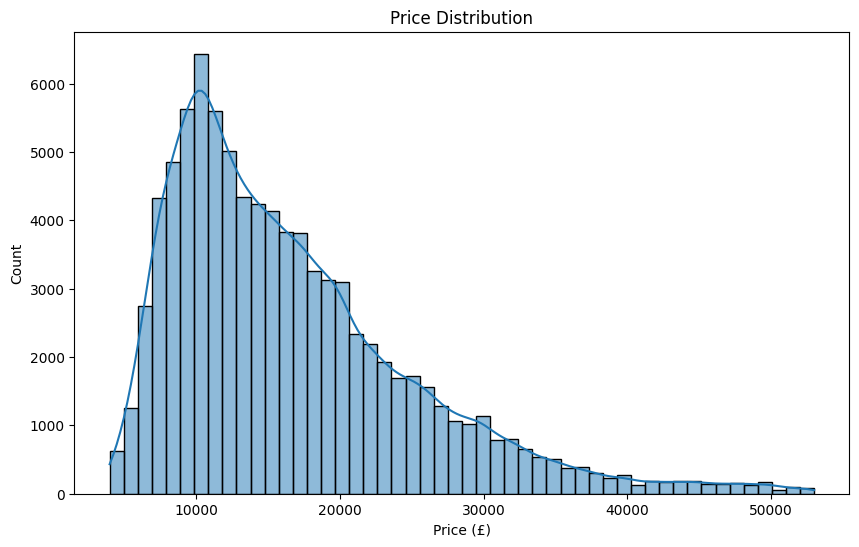

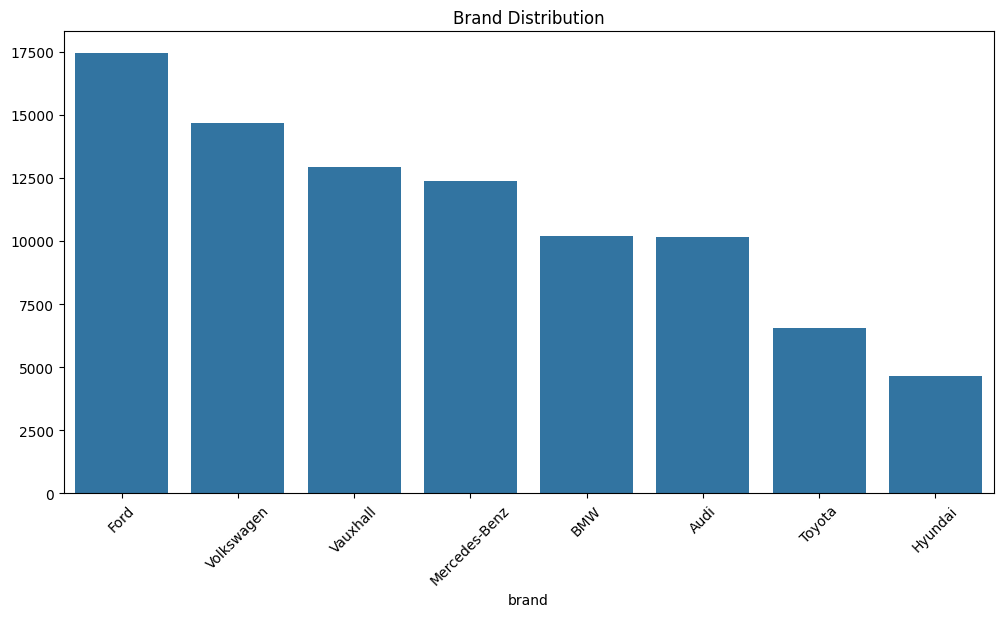

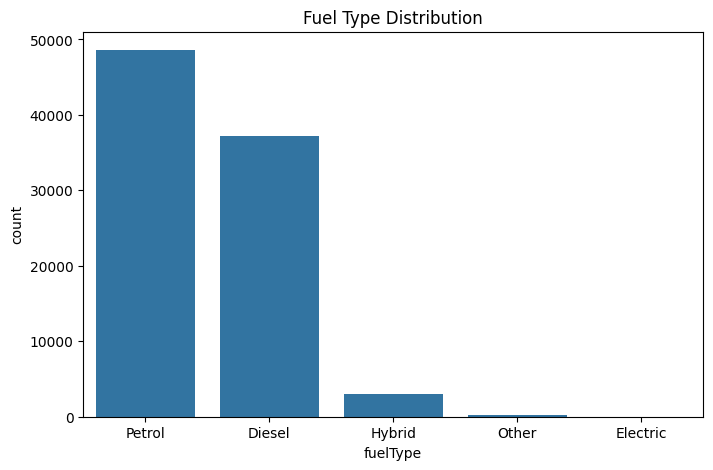

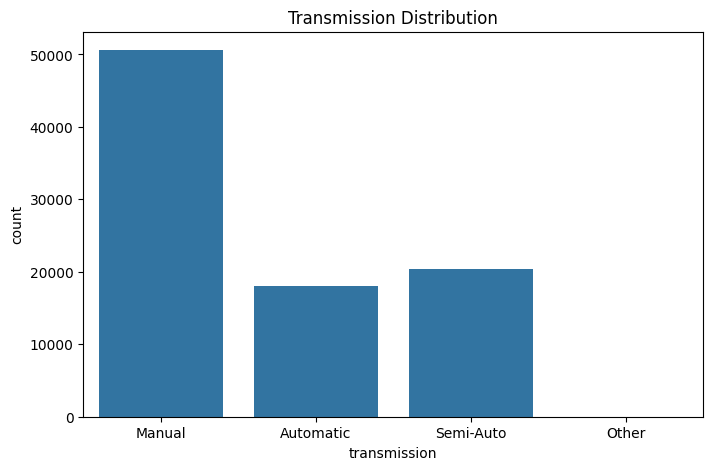

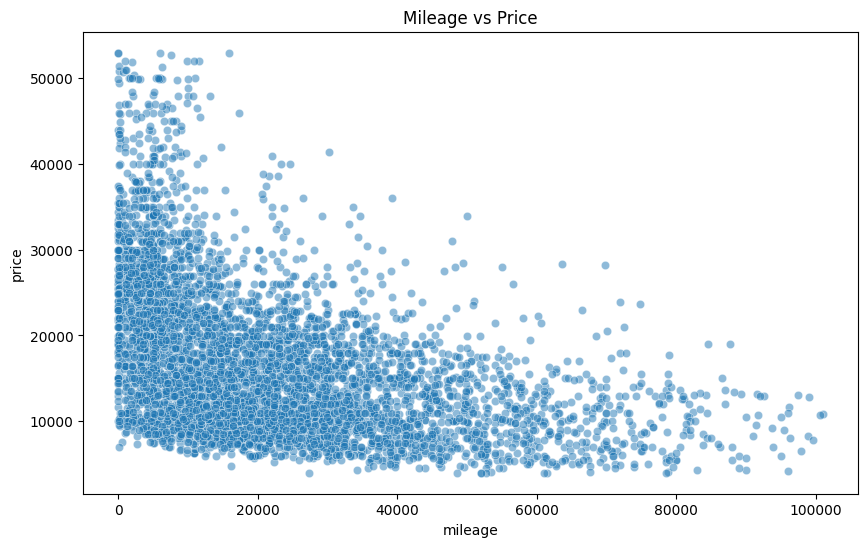

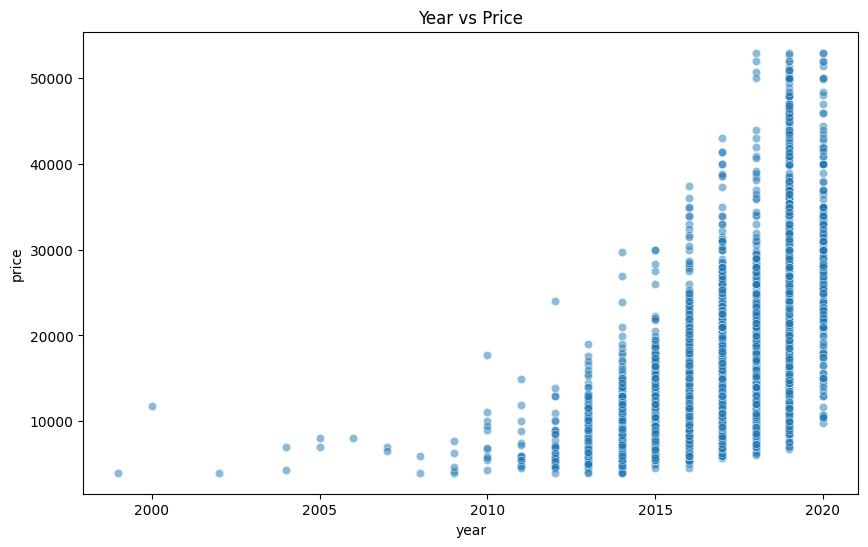

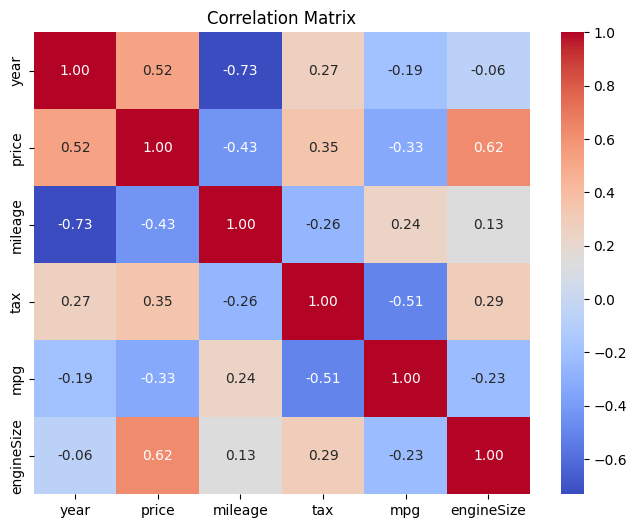


🚗 Top 15 Most Frequent Models:



model
Fiesta      6414
Golf        4748
Focus       4454
C Class     3613
Polo        3219
Corsa       3177
Astra       2572
A Class     2416
3 Series    2370
Kuga        2199
Mokka X     2111
Yaris       2074
1 Series    1936
Aygo        1910
E Class     1878
Name: count, dtype: int64


✅ CELL 4 Completed Successfully


In [4]:
# =========================================================
# CELL 4: Exploratory Data Analysis (EDA)
# =========================================================

print("🚀 Starting Exploratory Data Analysis...\n")

# ---------------------------------------------------------
# Dataset Overview
# ---------------------------------------------------------

print("=" * 70)
print("📊 DATASET OVERVIEW")
print("=" * 70)

print(f"\nShape: {df_model.shape}")

print("\nData Types:\n")
display(df_model.dtypes)

print("\nMissing Values:\n")
display(df_model.isnull().sum())

# ---------------------------------------------------------
# Numerical Summary
# ---------------------------------------------------------

print("\n📈 Numerical Statistics:\n")

display(
    df_model.describe().T
)

# ---------------------------------------------------------
# Price Distribution
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    df_model["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Count")

plt.show()

# ---------------------------------------------------------
# Brand Distribution
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

brand_counts = (
    df_model["brand"]
    .value_counts()
)

sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values
)

plt.title("Brand Distribution")

plt.xticks(rotation=45)

plt.show()

# ---------------------------------------------------------
# Fuel Type Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_model,
    x="fuelType"
)

plt.title("Fuel Type Distribution")

plt.show()

# ---------------------------------------------------------
# Transmission Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_model,
    x="transmission"
)

plt.title("Transmission Distribution")

plt.show()

# ---------------------------------------------------------
# Price vs Mileage
# ---------------------------------------------------------

sample_df = df_model.sample(

    min(5000, len(df_model)),

    random_state=RANDOM_STATE

)

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=sample_df,

    x="mileage",

    y="price",

    alpha=0.5

)

plt.title("Mileage vs Price")

plt.show()

# ---------------------------------------------------------
# Price vs Year
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=sample_df,

    x="year",

    y="price",

    alpha=0.5

)

plt.title("Year vs Price")

plt.show()

# ---------------------------------------------------------
# Correlation Matrix
# ---------------------------------------------------------

numeric_columns = df_model.select_dtypes(

    include=["int64", "float64"]

).columns

corr_matrix = (

    df_model[numeric_columns]

    .corr()

)

plt.figure(figsize=(8,6))

sns.heatmap(

    corr_matrix,

    annot=True,

    fmt=".2f",

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()

# ---------------------------------------------------------
# Top Models
# ---------------------------------------------------------

print("\n🚗 Top 15 Most Frequent Models:\n")

display(

    df_model["model"]

    .value_counts()

    .head(15)

)

print("\n✅ CELL 4 Completed Successfully")

In [5]:
# =========================================================
# CELL 5: Train Test Split
# =========================================================

print("🚀 Creating Train/Test Split...\n")

# ---------------------------------------------------------
# Target Column
# ---------------------------------------------------------

TARGET_COLUMN = "price"

# ---------------------------------------------------------
# Features & Target
# ---------------------------------------------------------

X = df_model.drop(
    columns=[TARGET_COLUMN]
)

y = df_model[TARGET_COLUMN]

# ---------------------------------------------------------
# Train Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)

# ---------------------------------------------------------
# Shape Information
# ---------------------------------------------------------

print("=" * 70)

print("📊 TRAIN TEST SPLIT SUMMARY")

print("=" * 70)

print(
    f"\nX Train Shape : {X_train.shape}"
)

print(
    f"X Test Shape  : {X_test.shape}"
)

print(
    f"\ny Train Shape : {y_train.shape}"
)

print(
    f"y Test Shape  : {y_test.shape}"
)

# ---------------------------------------------------------
# Original Numeric Features
# ---------------------------------------------------------

base_numeric_features = [

    "year",

    "mileage",

    "tax",

    "mpg",

    "engineSize"

]

# ---------------------------------------------------------
# Categorical Features
# ---------------------------------------------------------

categorical_features = [

    "brand",

    "model",

    "transmission",

    "fuelType"

]

print("\n🔢 Base Numeric Features:")

print(
    base_numeric_features
)

print("\n🔤 Categorical Features:")

print(
    categorical_features
)

# ---------------------------------------------------------
# Sample Data
# ---------------------------------------------------------

print("\n📋 Sample Training Data:")

display(
    X_train.head()
)

print(
    "\n✅ CELL 5 Completed Successfully"
)

🚀 Creating Train/Test Split...

📊 TRAIN TEST SPLIT SUMMARY

X Train Shape : (71211, 9)
X Test Shape  : (17803, 9)

y Train Shape : (71211,)
y Test Shape  : (17803,)

🔢 Base Numeric Features:
['year', 'mileage', 'tax', 'mpg', 'engineSize']

🔤 Categorical Features:
['brand', 'model', 'transmission', 'fuelType']

📋 Sample Training Data:


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand
69864,Adam,2018,Manual,11010,Petrol,145,53.3,1.2,Vauxhall
3054,A4,2017,Semi-Auto,14700,Petrol,30,55.4,2.0,Audi
68062,Mokka X,2018,Manual,32098,Petrol,150,39.2,1.4,Vauxhall
29861,C-MAX,2016,Manual,13624,Diesel,20,68.9,1.5,Ford
9311,Q3,2016,Automatic,52521,Diesel,145,54.3,2.0,Audi



✅ CELL 5 Completed Successfully


In [6]:
# =========================================================
# CELL 6: Feature Engineering Transformer
# =========================================================

from sklearn.preprocessing import FunctionTransformer

# تابع را از فایل جداگانه ایمپورت می‌کنیم
from features import create_features

print("🚀 Building Feature Engineering Transformer...\n")

# ---------------------------------------------------------
# Transformer
# ---------------------------------------------------------

feature_engineering = FunctionTransformer(

    create_features,

    validate=False

)

# ---------------------------------------------------------
# Test Transformation
# ---------------------------------------------------------

sample_features = feature_engineering.transform(

    X_train.head()

)

print("📋 Original Columns:\n")

print(
    list(X_train.columns)
)

print("\n📋 New Columns:\n")

print(
    list(sample_features.columns)
)

print("\n📋 Preview:\n")

display(
    sample_features.head()
)

print(
    "\n✅ Feature Engineering Transformer Ready"
)

print(
    "✅ CELL 6 Completed Successfully"
)

🚀 Building Feature Engineering Transformer...

📋 Original Columns:

['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'brand']

📋 New Columns:

['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'brand', 'car_age', 'mileage_per_year']

📋 Preview:



,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,car_age,mileage_per_year
69864,Adam,2018,Manual,11010,Petrol,145,53.3,1.2,Vauxhall,8,1223.333333
3054,A4,2017,Semi-Auto,14700,Petrol,30,55.4,2.0,Audi,9,1470.000000
68062,Mokka X,2018,Manual,32098,Petrol,150,39.2,1.4,Vauxhall,8,3566.444444
29861,C-MAX,2016,Manual,13624,Diesel,20,68.9,1.5,Ford,10,1238.545455
9311,Q3,2016,Automatic,52521,Diesel,145,54.3,2.0,Audi,10,4774.636364



✅ Feature Engineering Transformer Ready
✅ CELL 6 Completed Successfully


In [7]:
# =========================================================
# CELL 7: Data Preprocessing Pipeline
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

print("🚀 Building Preprocessing Pipeline...\n")

# ---------------------------------------------------------
# Numeric Features
# ---------------------------------------------------------

numeric_features = [

    "year",

    "mileage",

    "tax",

    "mpg",

    "engineSize",

    "car_age",

    "mileage_per_year"

]

# ---------------------------------------------------------
# Categorical Features
# ---------------------------------------------------------

categorical_features = [

    "brand",

    "model",

    "transmission",

    "fuelType"

]

# ---------------------------------------------------------
# Numeric Pipeline
# ---------------------------------------------------------

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        )

    ]

)

# ---------------------------------------------------------
# Categorical Pipeline
# ---------------------------------------------------------

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",

            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)

# ---------------------------------------------------------
# Column Transformer
# ---------------------------------------------------------

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",

            numeric_transformer,

            numeric_features
        ),

        (
            "cat",

            categorical_transformer,

            categorical_features
        )

    ],

    remainder="drop"

)

# ---------------------------------------------------------
# Test Full Pipeline
# ---------------------------------------------------------

test_pipeline = Pipeline([

    (
        "feature_engineering",
        feature_engineering
    ),

    (
        "preprocessor",
        preprocessor
    )

])

# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

X_preview = test_pipeline.fit_transform(

    X_train.head(100)

)

print(
    f"✅ Original Shape : "
    f"{X_train.head(100).shape}"
)

print(
    f"✅ Processed Shape : "
    f"{X_preview.shape}"
)

# ---------------------------------------------------------
# Feature Count
# ---------------------------------------------------------

feature_names = (

    test_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()

)

print(
    f"\n📊 Total Features After Encoding: "
    f"{len(feature_names)}"
)

print(
    "\n🔍 Sample Feature Names:"
)

for feature in feature_names[:20]:

    print(feature)

print(
    "\n✅ CELL 7 Completed Successfully"
)

print(
    "🚀 Preprocessing Pipeline Ready"
)

🚀 Building Preprocessing Pipeline...

✅ Original Shape : (100, 9)
✅ Processed Shape : (100, 68)

📊 Total Features After Encoding: 68

🔍 Sample Feature Names:
num__year
num__mileage
num__tax
num__mpg
num__engineSize
num__car_age
num__mileage_per_year
cat__brand_Audi
cat__brand_BMW
cat__brand_Ford
cat__brand_Hyundai
cat__brand_Mercedes-Benz
cat__brand_Toyota
cat__brand_Vauxhall
cat__brand_Volkswagen
cat__model_ 1 Series
cat__model_ 2 Series
cat__model_ 3 Series
cat__model_ 5 Series
cat__model_ A Class

✅ CELL 7 Completed Successfully
🚀 Preprocessing Pipeline Ready


In [8]:
feature_names = (
    test_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print(len(feature_names))

68


In [9]:
# =========================================================
# CELL 8: Baseline Models Training
# =========================================================

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import lightgbm as lgb

import xgboost as xgb

print("🚀 Training Baseline Models...\n")

# ---------------------------------------------------------
# Models
# ---------------------------------------------------------

models = {

    "Linear Regression":

        LinearRegression(),

    "Random Forest":

        RandomForestRegressor(

            n_estimators=300,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),

    "Extra Trees":

        ExtraTreesRegressor(

            n_estimators=300,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),

    "LightGBM":

        lgb.LGBMRegressor(

            n_estimators=300,

            learning_rate=0.05,

            random_state=RANDOM_STATE,

            verbose=-1

        ),

    "XGBoost":

        xgb.XGBRegressor(

            objective="reg:squarederror",

            n_estimators=300,

            learning_rate=0.05,

            random_state=RANDOM_STATE,

            n_jobs=-1

        )

}

# ---------------------------------------------------------
# Containers
# ---------------------------------------------------------

trained_models = {}

results = []

# ---------------------------------------------------------
# Training Loop
# ---------------------------------------------------------

for model_name, model in models.items():

    print(f"\n🚀 Training {model_name} ...")

    pipeline = Pipeline([

        (
            "feature_engineering",
            feature_engineering
        ),

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )

    ])

    pipeline.fit(
        X_train,
        y_train
    )

    preds = pipeline.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        preds
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    trained_models[
        model_name
    ] = pipeline

    results.append({

        "Model": model_name,

        "R2 Score": round(
            r2,
            4
        ),

        "MAE": round(
            mae,
            2
        ),

        "RMSE": round(
            rmse,
            2
        )

    })

    print(
        f"R² = {r2:.4f}"
    )

# ---------------------------------------------------------
# Results Table
# ---------------------------------------------------------

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(

    by="R2 Score",

    ascending=False

)

print("\n")
print("=" * 70)

print("🏆 MODEL COMPARISON")

print("=" * 70)

display(
    results_df
)

# ---------------------------------------------------------
# Best Model
# ---------------------------------------------------------

best_model_name = (
    results_df.iloc[0]["Model"]
)

best_model = (
    trained_models[
        best_model_name
    ]
)

best_r2 = (
    results_df.iloc[0]["R2 Score"]
)

print(
    f"\n🏆 Best Model: "
    f"{best_model_name}"
)

print(
    f"🎯 Best R²: "
    f"{best_r2:.4f}"
)

print(
    "\n✅ CELL 8 Completed Successfully"
)

🚀 Training Baseline Models...


🚀 Training Linear Regression ...
R² = 0.8918

🚀 Training Random Forest ...
R² = 0.9617

🚀 Training Extra Trees ...
R² = 0.9578

🚀 Training LightGBM ...
R² = 0.9574

🚀 Training XGBoost ...
R² = 0.9496


🏆 MODEL COMPARISON


,Model,R2 Score,MAE,RMSE
1,Random Forest,0.9617,1107.91,1678.31
2,Extra Trees,0.9578,1149.15,1761.80
3,LightGBM,0.9574,1236.62,1770.74
4,XGBoost,0.9496,1355.88,1925.37
0,Linear Regression,0.8918,1976.72,2822.43



🏆 Best Model: Random Forest
🎯 Best R²: 0.9617

✅ CELL 8 Completed Successfully


In [10]:
# =========================================================
# CELL 9: Lightweight XGBoost Tuning
# =========================================================

from sklearn.model_selection import RandomizedSearchCV

print("🚀 Starting Lightweight XGBoost Tuning...\n")

# ---------------------------------------------------------
# XGBoost Pipeline
# ---------------------------------------------------------

xgb_pipeline = Pipeline([

    (
        "feature_engineering",
        feature_engineering
    ),

    (
        "preprocessor",
        preprocessor
    ),

    (
        "model",

        xgb.XGBRegressor(

            objective="reg:squarederror",

            random_state=RANDOM_STATE,

            n_jobs=4

        )
    )

])

# ---------------------------------------------------------
# Smaller Search Space
# ---------------------------------------------------------

param_grid = {

    "model__n_estimators": [
        300,
        500
    ],

    "model__max_depth": [
        4,
        6,
        8
    ],

    "model__learning_rate": [
        0.03,
        0.05,
        0.1
    ],

    "model__subsample": [
        0.8,
        1.0
    ],

    "model__colsample_bytree": [
        0.8,
        1.0
    ]

}

# ---------------------------------------------------------
# Random Search
# ---------------------------------------------------------

random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=param_grid,

    n_iter=8,

    cv=3,

    scoring="r2",

    random_state=RANDOM_STATE,

    verbose=2,

    n_jobs=1

)

# ---------------------------------------------------------
# Train
# ---------------------------------------------------------

random_search.fit(

    X_train,

    y_train

)

# ---------------------------------------------------------
# Best Model
# ---------------------------------------------------------

best_model = random_search.best_estimator_

best_params = random_search.best_params_

# ---------------------------------------------------------
# Prediction
# ---------------------------------------------------------

preds = best_model.predict(
    X_test
)

# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------

final_r2 = r2_score(
    y_test,
    preds
)

final_mae = mean_absolute_error(
    y_test,
    preds
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

# ---------------------------------------------------------
# Results
# ---------------------------------------------------------

print("\n" + "=" * 70)

print("🏆 XGBOOST TUNING RESULTS")

print("=" * 70)

print("\nBest Parameters:\n")

for key, value in best_params.items():

    print(
        f"{key}: {value}"
    )

print("\n" + "=" * 70)

print("📊 FINAL RESULTS")

print("=" * 70)

print(
    f"\nR² Score : {final_r2:.4f}"
)

print(
    f"MAE      : {final_mae:.2f}"
)

print(
    f"RMSE     : {final_rmse:.2f}"
)

best_model_name = "Tuned XGBoost"

best_r2 = final_r2

print(
    "\n✅ CELL 9 Completed Successfully"
)

🚀 Starting Lightweight XGBoost Tuning...

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__n_estimators=300, model__subsample=0.8; total time=   1.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__n_estimators=300, model__subsample=0.8; total time=   1.0s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=6, model__n_estimators=300, model__subsample=0.8; total time=   1.0s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=4, model__n_estimators=500, model__subsample=0.8; total time=   1.4s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=4, model__n_estimators=500, model__subsample=0.8; total time=   1.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=4, model__n_estimators=500, model__subsample=0.8; total time=   

In [11]:
# %%
# =========================================================
# CELL 10: Cross Validation & Model Stability
# =========================================================

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

print("🚀 Starting Cross Validation for the Best Model...\n")

# ---------------------------------------------------------
# Define K-Fold Strategy
# ---------------------------------------------------------
kf = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# Run Cross Validation
# ---------------------------------------------------------
print("⚙️ Running 5-Fold CV (This might take a minute)...\n")

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------
print("=" * 70)
print("📊 CROSS VALIDATION RESULTS (5-Fold)")
print("=" * 70)

print(f"\nIndividual CV R² Scores : {np.round(cv_scores, 4)}")
print(f"\n🎯 CV Mean (R²)         : {cv_mean:.4f}")
print(f"📉 CV Std Deviation     : {cv_std:.4f}")

# ---------------------------------------------------------
# Stability Analysis
# ---------------------------------------------------------
print("\n" + "-" * 70)
if cv_std < 0.01:
    print("✅ STATUS: OUTSTANDING STABILITY")
    print("The model is highly robust. Variance across folds is practically zero.")
elif cv_std < 0.03:
    print("✅ STATUS: GOOD STABILITY")
    print("The model is reliable and generalizes well to unseen data.")
else:
    print("⚠️ STATUS: HIGH VARIANCE DETECTED")
    print("The model performance fluctuates. Consider regularization or more data.")
print("-" * 70)

print("\n✅ CELL 10 Completed Successfully")

🚀 Starting Cross Validation for the Best Model...

⚙️ Running 5-Fold CV (This might take a minute)...

📊 CROSS VALIDATION RESULTS (5-Fold)

Individual CV R² Scores : [0.9658 0.9655 0.9652 0.9661 0.9647]

🎯 CV Mean (R²)         : 0.9655
📉 CV Std Deviation     : 0.0005

----------------------------------------------------------------------
✅ STATUS: OUTSTANDING STABILITY
The model is highly robust. Variance across folds is practically zero.
----------------------------------------------------------------------

✅ CELL 10 Completed Successfully


🚀 Extracting Feature Importance from the Best Model...

📊 TOP 20 MOST IMPORTANT FEATURES


,Feature,Importance
0,transmission_Manual,0.207106
1,engineSize,0.047279
2,brand_Vauxhall,0.037928
3,brand_Mercedes-Benz,0.031001
4,model_ Yaris,0.024524
5,brand_Audi,0.023278
6,model_ Aygo,0.020825
7,fuelType_Petrol,0.019131
8,model_ Corsa,0.017762
9,year,0.016795


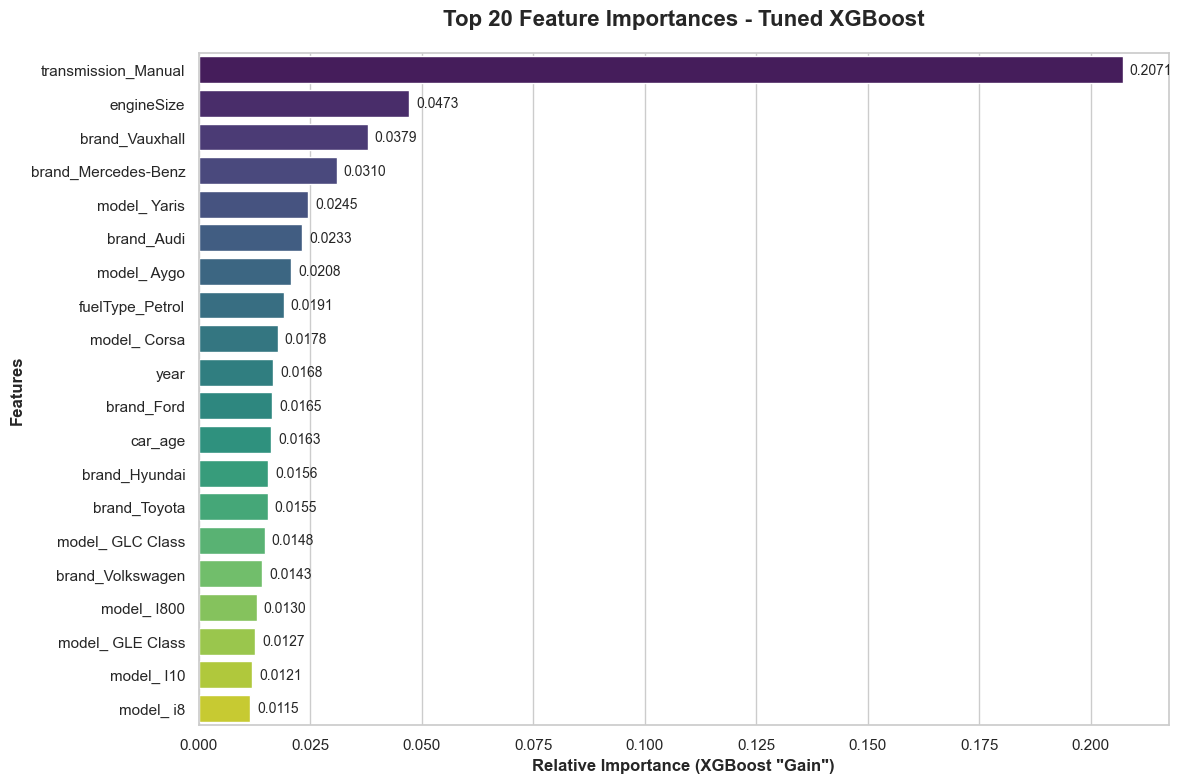


✅ CELL 11 Completed Successfully


In [12]:
# %%
# =========================================================
# CELL 11: Feature Importance Analysis
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Extracting Feature Importance from the Best Model...\n")

# ---------------------------------------------------------
# 1. Retrieve the Model from Pipeline
# ---------------------------------------------------------
# پایپ‌لاین ما سه بخش داشت: feature_engineering, preprocessor, model
xgb_regressor = best_model.named_steps["model"]

# ---------------------------------------------------------
# 2. Extract Feature Names
# ---------------------------------------------------------
preprocessor_step = best_model.named_steps["preprocessor"]
feature_names = preprocessor_step.get_feature_names_out()

# پاک‌سازی نام ویژگی‌ها (حذف پیشوندهای اضافی مثل 'num__' یا 'cat__')
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "") 
    for name in feature_names
]

# ---------------------------------------------------------
# 3. Create Importance DataFrame
# ---------------------------------------------------------
importances = xgb_regressor.feature_importances_

importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Importance": importances
})

# مرتب‌سازی بر اساس بیشترین اهمیت
importance_df = importance_df.sort_values(
    by="Importance", 
    ascending=False
).reset_index(drop=True)

# انتخاب 20 ویژگی برتر برای نمایش
top_n = 20
top_importance_df = importance_df.head(top_n)

# ---------------------------------------------------------
# 4. Display Text Summary
# ---------------------------------------------------------
print("=" * 70)
print(f"📊 TOP {top_n} MOST IMPORTANT FEATURES")
print("=" * 70)

display(top_importance_df)

# ---------------------------------------------------------
# 5. Visualize with Seaborn
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_importance_df,
    x="Importance",
    y="Feature",
    palette="viridis"
)

# اضافه کردن مقادیر عددی روی نمودار
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.4f}',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.title(f'Top {top_n} Feature Importances - Tuned XGBoost', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Relative Importance (XGBoost "Gain")', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ CELL 11 Completed Successfully")

In [13]:
# %%
# =========================================================
# CELL 12: Exporting the Production Pipeline
# =========================================================

import joblib
import os

print("🚀 Exporting the Final Production Pipeline...\n")

# ---------------------------------------------------------
# Define Filename
# ---------------------------------------------------------
pipeline_filename = "production_car_price_pipeline.pkl"

# ---------------------------------------------------------
# Save the Model
# ---------------------------------------------------------
try:
    # ذخیره کل پایپ‌لاین (شامل پیش‌پردازش و مدل) در یک فایل
    joblib.dump(best_model, pipeline_filename)
    
    # بررسی موفقیت‌آمیز بودن ساخت فایل
    if os.path.exists(pipeline_filename):
        file_size_mb = os.path.getsize(pipeline_filename) / (1024 * 1024)
        
        print("=" * 70)
        print("🎉 PIPELINE SAVED SUCCESSFULLY! 🎉")
        print("=" * 70)
        print(f"\n✅ Filename  : {pipeline_filename}")
        print(f"📦 File Size : {file_size_mb:.2f} MB")
        
    else:
        print("\n❌ Error: File was not created.")

except Exception as e:
    print(f"\n❌ Failed to save pipeline. Error: {e}")

# ---------------------------------------------------------
# Final Project Status
# ---------------------------------------------------------
print("\n" + "-" * 70)
print("🏁 JUPYTER NOTEBOOK PHASE COMPLETE 🏁")
print("-" * 70)
print("تمامی مراحل شامل پاک‌سازی، مهندسی ویژگی‌ها، آموزش و ارزیابی به پایان رسید.")
print("مدل شما اکنون آماده استقرار (Deployment) در یک سرور واقعی است.")
print("\n✅ CELL 12 Completed Successfully")

🚀 Exporting the Final Production Pipeline...

🎉 PIPELINE SAVED SUCCESSFULLY! 🎉

✅ Filename  : production_car_price_pipeline.pkl
📦 File Size : 3.97 MB

----------------------------------------------------------------------
🏁 JUPYTER NOTEBOOK PHASE COMPLETE 🏁
----------------------------------------------------------------------
تمامی مراحل شامل پاک‌سازی، مهندسی ویژگی‌ها، آموزش و ارزیابی به پایان رسید.
مدل شما اکنون آماده استقرار (Deployment) در یک سرور واقعی است.

✅ CELL 12 Completed Successfully


In [14]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nPKL Files:")

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

Current Directory:
f:\final project ml\Finals

PKL Files:
f:\final project ml\Finals\production_car_price_pipeline.pkl


In [15]:
from sklearn.preprocessing import FunctionTransformer

def create_features(df):

    df = df.copy()

    CURRENT_YEAR = 2026

    df["car_age"] = (
        CURRENT_YEAR - df["year"]
    ).clip(lower=0)

    df["mileage_per_year"] = (
        df["mileage"] /
        (df["car_age"] + 1)
    )

    return df
import joblib
loaded_pipeline = joblib.load(
    "production_car_price_pipeline.pkl"
)

print(
    loaded_pipeline.named_steps["model"]
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=4, num_parallel_tree=None, ...)


In [16]:
# %%
# =========================================================
# CELL 13: FastAPI Backend Simulation (Final Test)
# =========================================================

import joblib
import pandas as pd
import time

print("🚀 Starting Production Simulation Test...\n")

# ---------------------------------------------------------
# 1. Load the Saved Pipeline
# ---------------------------------------------------------
pipeline_filename = "production_car_price_pipeline.pkl"

try:
    production_model = joblib.load(pipeline_filename)
    print("✅ Pipeline loaded successfully from disk.")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load pipeline. Error: {e}")

# ---------------------------------------------------------
# 2. Mock Frontend Request (JSON format)
# ---------------------------------------------------------
# فرض کنید کاربر در سایت این اطلاعات را پر کرده و دکمه "تخمین قیمت" را زده است
mock_json_request = {
    "brand": "BMW",
    "model": "X5",
    "year": 2019,
    "transmission": "Semi-Auto",
    "mileage": 35000,
    "fuelType": "Diesel",
    "tax": 145,
    "mpg": 40.5,
    "engineSize": 3.0
}

print("\n📥 Received Request from Frontend:")
display(mock_json_request)

# ---------------------------------------------------------
# 3. Process & Predict
# ---------------------------------------------------------
start_time = time.time()

# تبدیل دیکشنری جیسون به دیتافریم (تنها کاری که در FastAPI باید انجام دهیم)
df_input = pd.DataFrame([mock_json_request])

# پیش‌بینی قیمت (پایپ‌لاین به طور خودکار تمام Feature Engineering ها را روی این یک سطر اعمال می‌کند)
predicted_price = production_model.predict(df_input)[0]

end_time = time.time()

# ---------------------------------------------------------
# 4. Response
# ---------------------------------------------------------
print("\n" + "=" * 70)
print("🎯 API RESPONSE SIMULATION")
print("=" * 70)

print(f"\n🚙 Car            : {mock_json_request['brand']} {mock_json_request['model']} ({mock_json_request['year']})")
print(f"💰 Estimated Price: £ {predicted_price:,.2f}")
print(f"⏱️ Response Time  : {(end_time - start_time) * 1000:.2f} ms")

print("\n" + "=" * 70)
print("🎉 MACHINE LEARNING PHASE OFFICIALLY COMPLETED! 🎉")
print("=" * 70)

🚀 Starting Production Simulation Test...

✅ Pipeline loaded successfully from disk.

📥 Received Request from Frontend:


{'brand': 'BMW',
 'model': 'X5',
 'year': 2019,
 'transmission': 'Semi-Auto',
 'mileage': 35000,
 'fuelType': 'Diesel',
 'tax': 145,
 'mpg': 40.5,
 'engineSize': 3.0}


🎯 API RESPONSE SIMULATION

🚙 Car            : BMW X5 (2019)
💰 Estimated Price: £ 33,585.66
⏱️ Response Time  : 12.43 ms

🎉 MACHINE LEARNING PHASE OFFICIALLY COMPLETED! 🎉
